In [26]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import pandas as pd
dataset = pd.read_csv("stk_data.csv", parse_dates=['Date'], index_col='Date')

In [2]:
dataset

,Close,High,Low,Open,Volume
Date,,,,,
2013-01-01,176.018555,177.253853,175.683556,176.709489,6831351
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898
2013-01-03,180.216461,180.478168,176.835111,177.672587,17266808
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377
2013-01-07,179.347595,182.362542,178.342613,181.252877,15307180
...,...,...,...,...,...
2022-12-26,1152.220215,1160.414342,1137.772122,1147.974874,5990242
2022-12-27,1161.646973,1163.518550,1148.203131,1154.936462,5763271
2022-12-28,1161.532837,1163.975064,1151.056230,1158.588423,7459393


In [3]:
#start date and end date
from datetime import date, timedelta
import pandas as pd
start_date = pd.to_datetime("2013-01-01")
end_date = pd.to_datetime("2019-02-04") - timedelta(days=1) #Excluding last

# List of all dates
all_date=pd.date_range(start_date, end_date, freq='D')

In [4]:
all_date

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2019-01-25', '2019-01-26', '2019-01-27', '2019-01-28',
               '2019-01-29', '2019-01-30', '2019-01-31', '2019-02-01',
               '2019-02-02', '2019-02-03'],
              dtype='datetime64[ns]', length=2225, freq='D')

In [5]:
dummyDate=dataset

In [6]:
# Align data with full calendar
dummyDate = dataset.reindex(all_date
                           
# Fill missing values)
dummyDate = dummyDate.fillna(method='ffill')

C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_18784\4280263077.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dummyDate = dummyDate.fillna(method='ffill')


In [7]:
dummyDate

,Close,High,Low,Open,Volume
2013-01-01,176.018555,177.253853,175.683556,176.709489,6831351.0
2013-01-02,177.536530,179.221978,176.405928,176.709522,13441898.0
2013-01-03,180.216461,180.478168,176.835111,177.672587,17266808.0
2013-01-04,180.446793,181.022562,178.709017,180.457261,13306377.0
2013-01-05,180.446793,181.022562,178.709017,180.457261,13306377.0
...,...,...,...,...,...
2019-01-30,531.708496,544.737778,529.662949,540.290947,17164298.0
2019-01-31,545.693909,546.827850,534.065429,534.510100,22279301.0
2019-02-01,555.832520,558.078198,545.649313,548.739866,20187323.0
2019-02-02,555.832520,558.078198,545.649313,548.739866,20187323.0


<h5 style="color:darkblue;"> 
• These values show how the stock moved within a single day.<br> <br> 
• Open → Price when the market started that day<br><br>  
• Close → Price when the market ended that day<br> <br> 
• High → Highest price reached during the day<br> <br> 
• Low → Lowest price reached during the day<br> 
</h5>

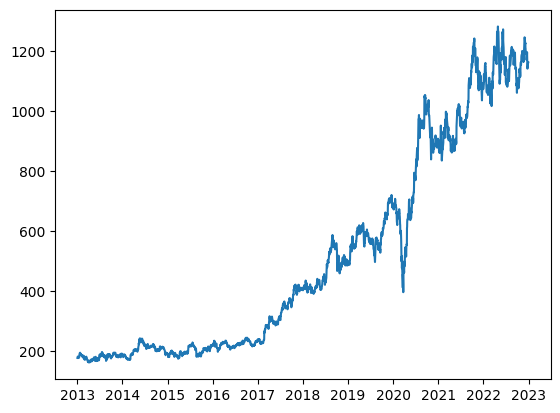

In [8]:
import matplotlib.pyplot as plt
plt.plot(dataset["Close"])

<h5 style="color:darkblue;"> 
• This graph shows the closing price trend over time.<br><br>
• The stock’s closing price shows an overall upward trend with some fluctuations.
</h5>

<Figure size 1600x500 with 0 Axes>

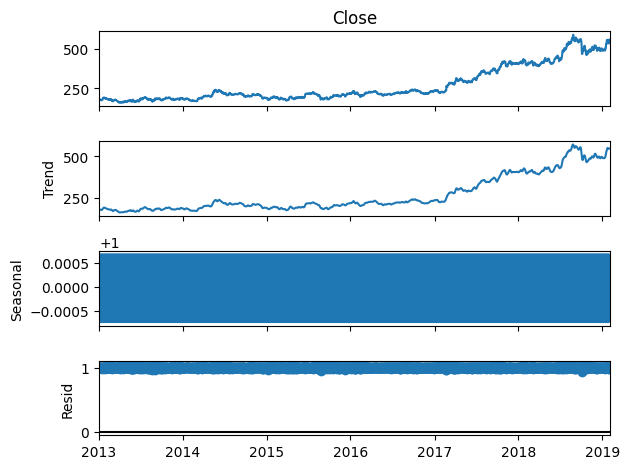

In [10]:
# Import function to break time series into components 
from statsmodels.tsa.seasonal import seasonal_decompose  

# Decompose closing price into trend, seasonal, and residual parts (multiplicative --> Value = Trend × Seasonal × Noise)
result = seasonal_decompose(dummyDate["Close"], model='multiplicative')
plt.figure(figsize=(16,5))
result.plot()
plt.show()

<h5 style="color:darkblue;"> 
• Close (Observed): Original data showing actual stock price movement over time<br> <br> 
• Trend: Shows long-term upward movement of the stock (growth pattern)<br> <br> 
• Seasonal: Almost flat → No clear repeating pattern (no seasonality)<br> <br> 
• Residual (Noise): Random fluctuations → unexplained variations / noise<br>
</h5>

<Figure size 1600x500 with 0 Axes>

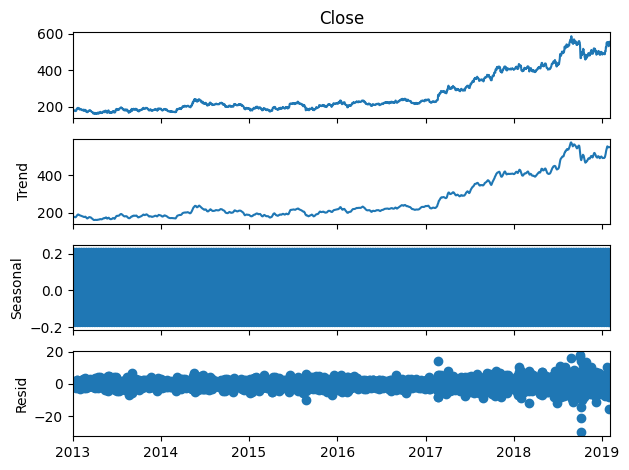

In [11]:
# Break closing price into trend + seasonal + residual assuming linear (additive) relationship
result = seasonal_decompose(dummyDate["Close"], model='additive')  # Additive model --> Value = Trend + Seasonal + Noise
plt.figure(figsize=(16,5))
result.plot()
plt.show()

<h5 style="color:darkblue;"> 
• Close (Observed): Shows actual stock price - overall increasing trend <br><br>
• Trend: Clear long-term upward movement (stock growth)<br><br>
• Seasonal: Flat line → No repeating seasonal pattern <br><br>
• Residual: Random scattered points → noise / unexplained variation<br>
</h5>

In [15]:
# ADF Test
# Function to print out results in customised manner

# Import ADF test function to check stationarity
from statsmodels.tsa.stattools import adfuller

def adf_test(timeseries, df, ohlc):   # Define function to run ADF test on given time series data
    plt.figure(figsize=(16,5))
    
    print('Results of Dickey-Fuller Test:')        # Print heading for ADF test results
    dftest = adfuller(timeseries, autolag='AIC')   # Perform ADF test and automatically choose best lag using AIC
    
    dfoutput = pd.Series(
        dftest[0:4],
        index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])   # Store main ADF results into a labeled pandas Series
    
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value   # Add critical values (1%, 5%, 10%) to results
    
    print(dfoutput)    # Display ADF test results
    
    ans = dfoutput     # Store results in a variable for further use
    
    print("Condition:")                                        
    print("p-value<=0.05-->Accept Alternate Hypothesis")       
    print("p-value>0.05-->Accept Null Hypothesis")

    if (
    (ans['Test Statistic'] < ans["Critical Value (1%)"] or  # Check if test statistic is lower than strict threshold (1%)
     ans['Test Statistic'] < ans["Critical Value (5%)"] or  # Check if test statistic is lower than common threshold (5%)
     ans['Test Statistic'] < ans["Critical Value (10%)"])   # Check if test statistic is lower than relaxed threshold (10%)
    and ans["p-value"] < 0.05):                             # Ensure result is statistically significant (not random)
        
        
        # Explain condition for rejecting null hypothesis
        print("Condition: statistic < any critical value and p-value <0.05 to reject null hypothesis")
        
        # Reject null → data is NOT non-stationary
        print("Reject null hypothesis:Non Stationarity")

        # Accept alternate → data is stationary
        print("Accept Alternate hypothesis:Stationarity ")
        
        # Save result message as stationary
        message = "Stationarity based on ADH"

   # If condition not satisfied     
    else:
        print("Condition: statistic < any critical value and p-value <0.05 to reject null hypothesis") # Print condition again for clarity
        print("Accept null hypothesis:Non Stationarity ")   # Accept null → data is non-stationary
        print("Reject Alternate hypothesis:Stationarity ")  # Reject alternate → data is not stationary
        message = "Non-stationarity based on ADH"           # Save result message as non-stationary

    plt.plot(df.index, df[ohlc], label=ohlc)
    plt.legend(loc='best')
    plt.title("{}_{}_2013 to 2021".format(message, ohlc))
    plt.savefig("{}_ADH.png".format(ohlc))
    plt.show()

    return message

Results of Dickey-Fuller Test:
Test Statistic                    0.025408
p-value                           0.960584
#Lags Used                        5.000000
Number of Observations Used    2462.000000
Critical Value (1%)              -3.433009
Critical Value (5%)              -2.862715
Critical Value (10%)             -2.567395
dtype: float64
Condition:
p-value<=0.05-->Accept Alternate Hypothesis
p-value>0.05-->Accept Null Hypothesis
Condition: statistic < any critical value and p-value <0.05 to reject null hypothesis
Accept null hypothesis:Non Stationarity 
Reject Alternate hypothesis:Stationarity 


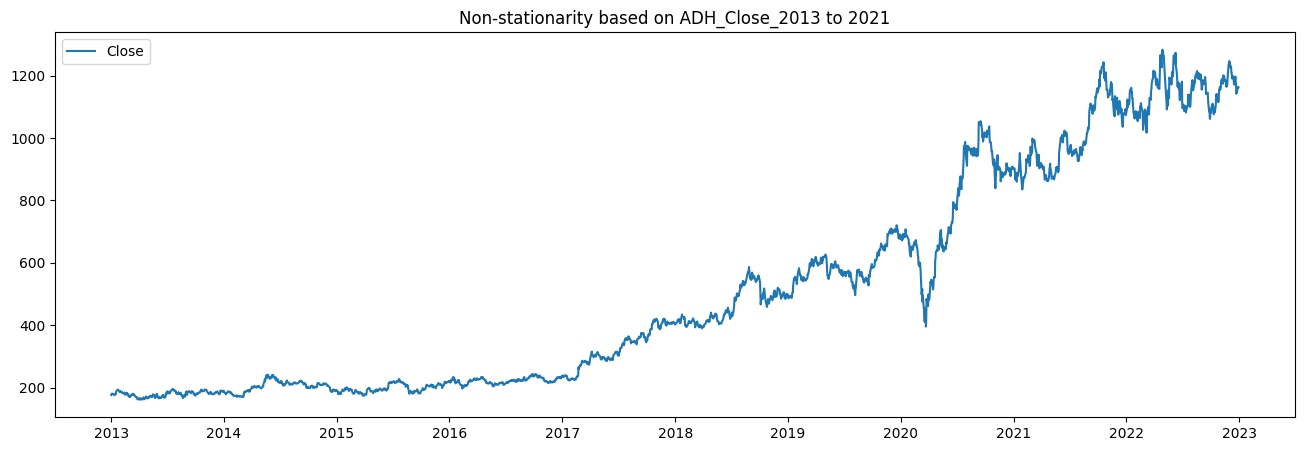

'Non-stationarity based on ADH'

In [16]:
adf_test(dataset["Close"], dataset, "Close")

<h5 style="color:darkblue;"> 
ADF Result:<br><br>
• Test Statistic is 0.025 → not sufficiently negative → weak evidence for stationarity<br> <br> 
• Critical Values are (-3.43, -2.86, -2.56) → Test Statistic is greater than all → condition fails<br> <br> 
• p-value is 0.96 → very high (>0.05) → result is not statistically significant<br> <br> 
• Therefore, we accept the Null Hypothesis (data is non-stationary)<br> <br> 
• Final conclusion: The time series is NON-STATIONARY<br>
</h5>

<h5 style="color:darkblue;"> 
Graph:<br><br> 
• The closing price shows a clear upward trend over time<br><br> 
• The mean is not constant → values are increasing continuously<br><br> 
• There are fluctuations, but overall trend dominates<br><br> 
• No stable pattern → confirms non-stationarity<br><br> 
• Final conclusion: The data is non-stationary due to trend</h5>

<h3 style="color:Green;"> 
Auto Correlation - Partial Auto Correlation
</h5>

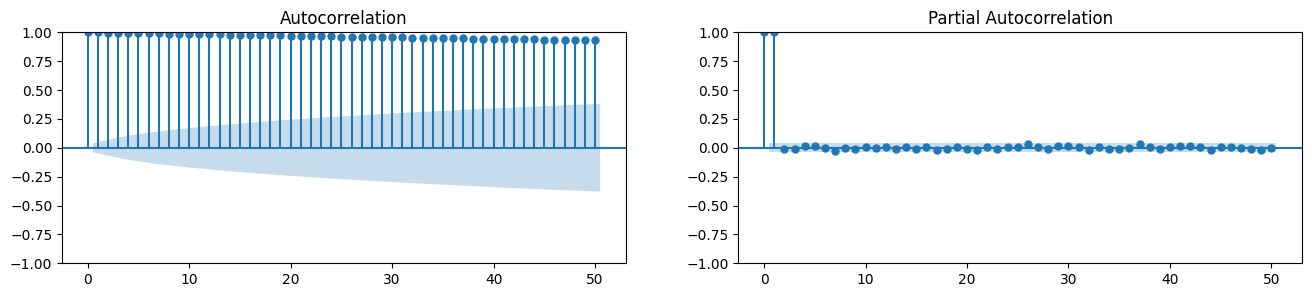

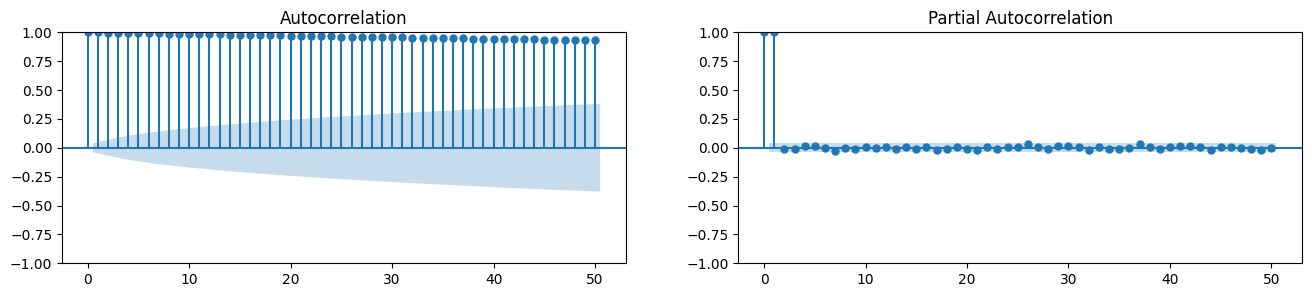

In [18]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1,2, figsize=(16,3), dpi=100)
plot_acf(dataset.Close.tolist(), lags=50, ax=axes[0])
plot_pacf(dataset.Close.tolist(), lags=50, ax=axes[1])

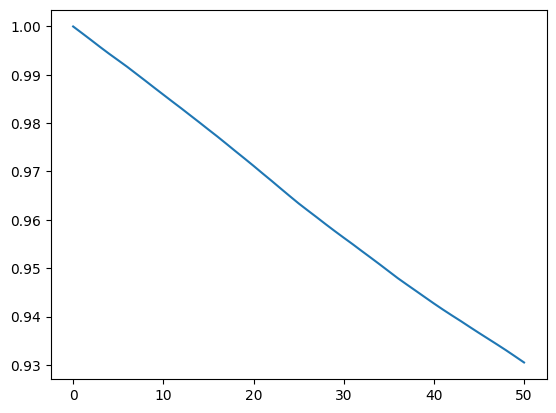

In [19]:
plt.plot(acf(dataset["Close"], nlags=50))

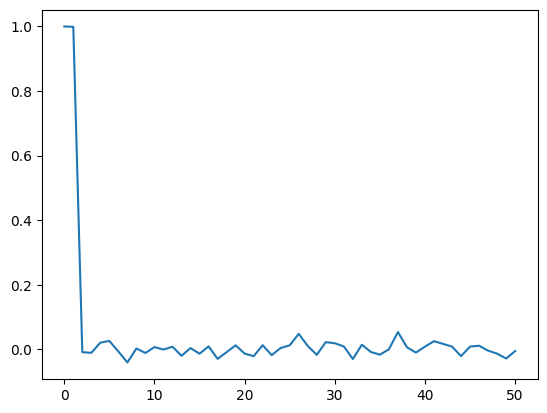

In [20]:
plt.plot(pacf(dataset["Close"], nlags=50))

<Axes: xlabel='y(t)', ylabel='y(t + 1)'>

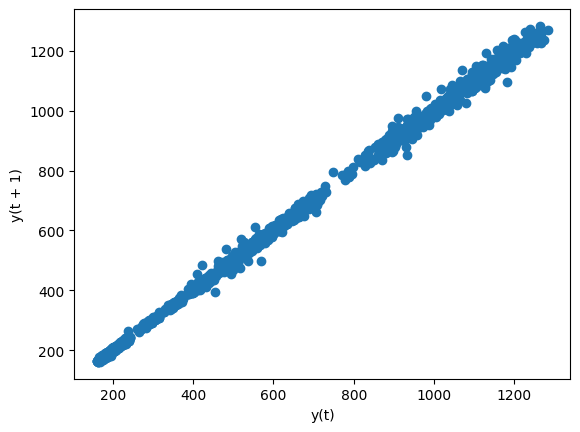

In [21]:
from pandas.plotting import lag_plot
lag_plot(dataset["Close"], lag=1)

<h3 style="color:Green;"> 
Forcastability
</h5>

#### ApEn Low - Forcastability is possibile
#### SampEn Low - Forcastability is possibile

In [22]:
# Function to measure randomness in data
def ApEn(U, m, r):  
    """Compute Approximate entropy"""
    
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])  # Find maximum difference between two patterns
    
    def _phi(m):
        x = [[U[j] for j in range(i, i + m)] for i in range(N - m + 1)]  # Create patterns of length m
        C = [len([1 for x_j in x if _maxdist(x_i, x_j) <= r]) / (N - m + 1.0) for x_i in x] # Count similar patterns (including itself)
        return (N - m + 1.0)**(-1) * sum(np.log(C))  # Take average log similarity
    
    N = len(U)  # Total number of data points
    return abs(_phi(m + 1) - _phi(m))  # Compare similarity between m and m+1 to measure randomness

In [23]:
import numpy as np

# Calculate Approximate Entropy for stock closing prices
print(ApEn(dataset["Close"], m=2, r=0.2 * np.std(dataset["Close"])))

C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_18784\356882779.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = [[U[j] for j in range(i, i + m)] for i in range(N - m + 1)]


0.05228600595586341


In [24]:
# Function to measure randomness more accurately
def SampEn(U, m, r):
    """Compute Sample entropy"""
    
    def _maxdist(x_i, x_j):
        return max([abs(ua - va) for ua, va in zip(x_i, x_j)])  # Find maximum difference between two patterns
    
    def _phi(m):
        x = [[U[j] for j in range(i, i + m)] for i in range(N - m + 1)]  # Create patterns of length m
        C = [len([1 for j in range(len(x)) if i != j and _maxdist(x[i], x[j]) <= r]) for i in range(len(x))]
        # Count similar patterns but exclude comparing with itself
        return sum(C)  # Total number of valid matches
    
    N = len(U) # Total number of data points
    return -np.log(_phi(m + 1) / _phi(m))  # Use ratio of matches to calculate entropy

In [25]:
import numpy as np

# Calculate Sample Entropy for stock closing prices
print(SampEn(dataset["Close"], m=2, r=0.2 * np.std(dataset["Close"])))

C:\Users\Default.DESKTOP-73FCCDO\AppData\Local\Temp\ipykernel_18784\404333264.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = [[U[j] for j in range(i, i + m)] for i in range(N - m + 1)]


0.020532848373365546
